In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hypertools as hyp
import quail
from scipy.stats import pearsonr as corr
from scipy.spatial.distance import cdist
from scipy.signal import resample

%matplotlib inline
sns.set_context('poster')
plt.rc('figure', figsize=(12, 8))

In [2]:
rawdir = '../../sherlock_behavioral_data/'

In [3]:
raw = pd.read_excel(rawdir+'Sherlock_Segments_1000_NN_2017.xlsx')
raw['Scene Segments'].fillna(method='ffill', inplace=True)
movie_annotations = raw[raw['Segment Number']>7]
movie_annotations = movie_annotations.reset_index(drop=True)
movie_annotations['Segment Number'] = pd.RangeIndex(len(movie_annotations.index))

In [4]:
# optimal params from sherlock study
ntopics = 100
m_wsize = 50
r_wsize = 10

# vectorizer parameters
vectorizer = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : ntopics,
        'learning_method' : 'batch',
        'random_state' : 0
    }
}

## model movie from hand-annotations

In [5]:
def model_movie(movie_text, m_wsize, ntopics, vec_params, sem_params):

    # create sliding window of text samples
    movie_windows = []
    for idx, sentence in enumerate(movie_text):
        movie_windows.append(','.join(movie_text[idx:idx+m_wsize]))

    # vectorizer and topic model parameters
    vectorizer = vec_params
    semantic = sem_params

    # use hypertools to create movie model
    movie_model = hyp.tools.format_data(movie_windows, vectorizer=vec_params, semantic=sem_params, corpus=movie_windows)[0]

    # sherlock scene description are by shot, not TR, so stretch the model to be in TRs
    ranges =[[d['Start Time (TRs, 1.5s)'],d['End Time (TRs, 1.5s)']] for i, d in movie_annotations.iterrows()] 
    expanded = []
    for i in range(1976):
        try:
            idx = np.where([i>=r[0] and i<=r[1] for r in ranges])[0][0]
            expanded.append(movie_model[idx, :])
        except:
            expanded.append(movie_model[0, :])

    # make movie windows accessible to model_recall function
    model_movie.movie_windows = movie_windows
    
    return np.array(expanded)

## single subject recall model

In [6]:
def model_recall(sub, r_wsize, ntopics, vec_params, sem_params, res=False):
    
    # load recall from text file
    recall = pd.read_csv(rawdir+'/NN'+str(sub)+' transcript.txt', header=None, sep='.', error_bad_lines=False, encoding='latin-1').values.tolist()[0][:-1]
    
    sent = []
    # separate sentences
    for sentence in recall:
        try:
            s = sentence.encode('utf-8').strip()
            sent.append(sentence)
        except AttributeError:
            pass # skip over nans
        
    # create sliding window of sentences
    recall_windows = []
    for idx, s in enumerate(sent):
        recall_windows.append(','.join(sent[idx:idx+r_wsize]))
    
    # use hypertools to create recall model
    recall_model = hyp.tools.format_data(recall_windows, vectorizer=vec_params, semantic=sem_params, corpus=model_movie.movie_windows)
    
    # resample model to match sherlock movie model
    if res:
        return resample(recall_model[0], 1976)
    
    else:
        return recall_model[0]


## make a list of all subjects' recall models

In [7]:
def model_all_subs(subs, r_wsize, ntopics, vec_params, sem_params):
    return [model_recall(sub, r_wsize, ntopics, vec_params, sem_params) for sub in subs]

## determine important features to movie/recall model match

In [8]:
def compare_mr_models(m_model, r_model):
    #return np.mean(np.diag(1-cdist(m_model, r_model, 'correlation')))
    return corr(pd.DataFrame(m_model).T.corr().values.ravel(), pd.DataFrame(r_model).T.corr().values.ravel())[0]

In [9]:
def drop_feature(df, feature):
    df_tmp = df.drop(feature, axis=1)
    return df_tmp

In [10]:
features_df = movie_annotations.loc[:,'Scene Details - A Level ':'Words on Screen ']
full_movie_text = features_df.apply(lambda x: ', '.join(x.fillna('')), axis=1).values.tolist()

In [11]:
# baseline movie/recall correlation
full_movie_model = model_movie(full_movie_text, m_wsize=m_wsize, ntopics=ntopics, vec_params=vectorizer, sem_params=semantic)
single_sub_rec_model = model_recall(12, r_wsize=r_wsize, ntopics=ntopics, vec_params=vectorizer, sem_params=semantic, res=True)
full_model_corrcoeff = compare_mr_models(full_movie_model, single_sub_rec_model)

In [12]:
corrs = {}
for feat in features_df.columns:
    partial_df = drop_feature(features_df,feat)
    partial_movie_text = partial_df.apply(lambda x: ', '.join(x.fillna('')), axis=1).values.tolist()
    partial_movie_model = model_movie(partial_movie_text, m_wsize=m_wsize, ntopics=ntopics, vec_params=vectorizer, sem_params=semantic)
    single_sub_rec_model = model_recall(12, r_wsize=r_wsize, ntopics=ntopics, vec_params=vectorizer, sem_params=semantic, res=True)
    corrcoeff = compare_mr_models(partial_movie_model, single_sub_rec_model)
    print('with ' + str(feat) + ' dropped, correlation is ' + str(corrcoeff))
    dists[feat] = corrcoeff
corrs['none'] = full_model_corrcoeff

with Scene Details - A Level  dropped, correlation is 0.3985956468089927
with Space-In/Outdoor dropped, correlation is 0.7039980053493289
with Name - All dropped, correlation is 0.707903297283788
with Name - Focus dropped, correlation is 0.6998910015133732
with Name - Speaking dropped, correlation is 0.6671601958512329
with Location dropped, correlation is 0.6850274823362923
with Camera Angle dropped, correlation is 0.6683054269244384
with Music Presence  dropped, correlation is 0.6728741212837607
with Words on Screen  dropped, correlation is 0.6770205401734309


In [16]:
corr_props = {}
for k, v in corrs.items():
    corr_props[k] = corrs[k]/corrs['none']

In [17]:
corr_props

{'Camera Angle': 0.9723551108896729,
 'Location': 0.9966849687499096,
 'Music Presence ': 0.9790023609813321,
 'Name - All': 1.0299682770754588,
 'Name - Focus': 1.0183107378300034,
 'Name - Speaking': 0.9706888498624271,
 'Scene Details - A Level ': 0.5799391995614007,
 'Space-In/Outdoor': 1.0242862484415407,
 'Words on Screen ': 0.9850352187688483,
 'none': 1.0}

In [85]:
pd.Series(corr_props).sort_values().index

Index(['Scene Details - A Level ', 'Name - Speaking', 'Camera Angle',
       'Music Presence ', 'Words on Screen ', 'Location', 'none',
       'Name - Focus', 'Space-In/Outdoor', 'Name - All'],
      dtype='object')

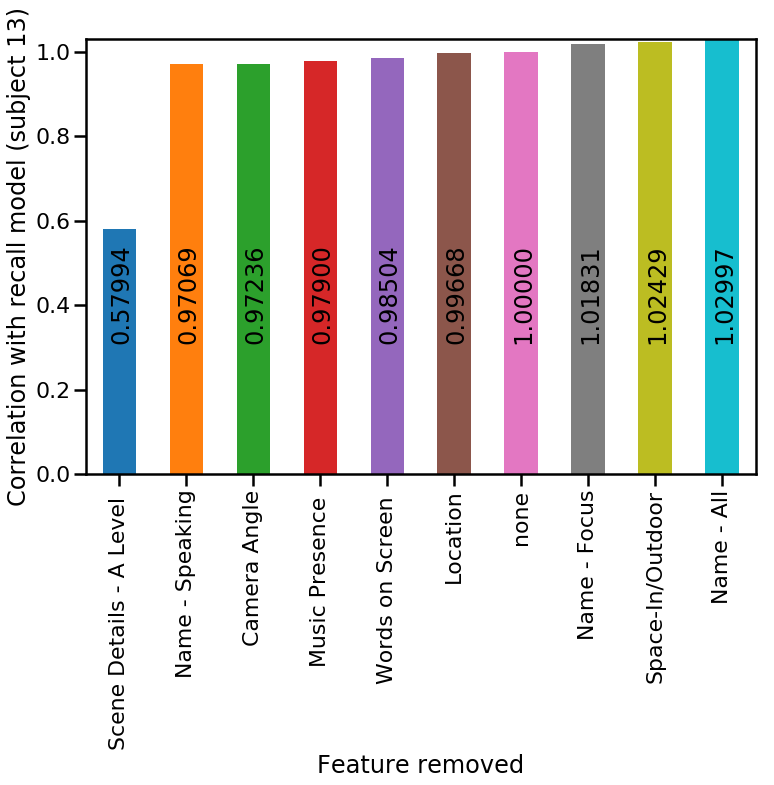

In [109]:
pd.Series(corr_props).sort_values().plot(kind='bar', ylim=[0,corr_props['Name - All']])
plt.ylabel('Correlation with recall model (subject 13)')
plt.xlabel('Feature removed')

for idx, val in enumerate(pd.Series(corr_props).sort_values()):
    plt.text(idx-.15, 0.5, '%.5f'%val, rotation=90)
    
plt.savefig('../figures/sherlock-dropfeat-m-r-corr.pdf', bbox_inches='tight')

In [ ]:
full_movie_model = model_movie(full_movie_text, m_wsize=m_wsize, ntopics=ntopics, vec_params=vectorizer, sem_params=semantic)

In [ ]:
ntopics = [1, 5, 10, 25, 50, 100, 250, 500]
v_wsize = [1, 5, 10, 25, 50, 100, 250, 500]
r_wsize = [1, 5, 10, 25, 50, 100, 250, 500]
hand_annotated = []

def compare_models(video, recall):
        return np.mean(np.diag(1 - cdist(video, recall, 'correlation')))
    
for i, t in enumerate(n_topics):
    for j, v in enumerate(wsize):
        for k, r in enumerate(r_wsize):
            video_model = <fit topic model>
            recall_models = <fit recall data for each subject>
            dists = [compare_models(video_model, recall_model) for recall_model in recall_models]
            grid[i,j,k] = np.corrcoef(hand_annotated, dists)
            
maxi, maxj, maxk  = np.argmax(grid)